# 📊 02 — Exploratory Data Analysis

**Project:** AI-Powered Sales Intelligence Platform  
**Notebook Purpose:** Analyze retail sales performance and extract actionable business insights.  
**Input:** `data/processed/cleaned_sales.csv`  
**Output:** `data/processed/monthly_sales.csv` (forecast-ready time series)  

---

### Pipeline Context

| Upstream | This Notebook | Downstream |
|---|---|---|
| `01_data_cleaning.ipynb` | **EDA & Insights** | `03_forecasting.ipynb`, AI Agent, Power BI |

> **Reference:** See [`docs/data_dictionary.md`](../docs/data_dictionary.md) for column definitions and usage notes.

---
## Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
import os

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.2f}".format)
warnings.filterwarnings("ignore")

# Plot styling
sns.set_theme(style="whitegrid", font_scale=1.05)
PALETTE = ["#2563EB", "#10B981", "#F59E0B", "#EF4444", "#8B5CF6", "#EC4899"]
sns.set_palette(PALETTE)

# Formatting helpers
def fmt_dollar(x, _=None):
    """Format number as $XXk or $X.XM."""
    if abs(x) >= 1_000_000:
        return f"${x/1_000_000:.1f}M"
    if abs(x) >= 1_000:
        return f"${x/1_000:.0f}k"
    return f"${x:,.0f}"

def fmt_pct(x, _=None):
    return f"{x:.1f}%"

print("✅ Setup complete.")

✅ Setup complete.


---
## Load Data

We load the cleaned dataset with `parse_dates` to ensure date columns are properly typed as `datetime64`.

In [2]:
DATA_PATH = os.path.join("..", "data", "processed", "cleaned_sales.csv")
if not os.path.exists(DATA_PATH):
    DATA_PATH = os.path.join("data", "processed", "cleaned_sales.csv")

df = pd.read_csv(DATA_PATH, parse_dates=["order_date", "ship_date"])

print(f"✅ Loaded {len(df):,} rows × {len(df.columns)} columns")
print(f"   order_date dtype: {df['order_date'].dtype}")
print(f"   ship_date  dtype: {df['ship_date'].dtype}")

✅ Loaded 9,994 rows × 27 columns
   order_date dtype: datetime64[us]
   ship_date  dtype: datetime64[us]


---
## 1 · Dataset Overview

A quick structural summary before diving into the analysis.

In [3]:
print("Dataset Overview")
print("=" * 50)
print(f"  Rows              : {df.shape[0]:,}")
print(f"  Columns           : {df.shape[1]}")
print(f"  Unique Orders     : {df['order_id'].nunique():,}")
print(f"  Unique Customers  : {df['customer_id'].nunique():,}")
print(f"  Unique Products   : {df['product_id'].nunique():,}")
print(f"  Date Range        : {df['order_date'].min().date()} → {df['order_date'].max().date()}")
print(f"  Span              : {(df['order_date'].max() - df['order_date'].min()).days} days ({df['order_year'].nunique()} years)")
print(f"  Regions           : {', '.join(sorted(df['region'].unique()))}")
print(f"  Categories        : {', '.join(sorted(df['category'].unique()))}")
print(f"  Sub-Categories    : {df['sub_category'].nunique()}")

Dataset Overview
  Rows              : 9,994
  Columns           : 27
  Unique Orders     : 5,009
  Unique Customers  : 793
  Unique Products   : 1,862
  Date Range        : 2014-01-03 → 2017-12-30
  Span              : 1457 days (4 years)
  Regions           : Central, East, South, West
  Categories        : Furniture, Office Supplies, Technology
  Sub-Categories    : 17


### Summary Statistics

In [4]:
df[["sales", "profit", "quantity", "discount", "profit_margin", "shipping_days"]].describe()

,sales,profit,quantity,discount,profit_margin,shipping_days
count,9994.00,9994.00,9994.00,9994.00,9994.00,9994.00
mean,229.86,28.66,3.79,0.16,0.12,3.96
std,623.25,234.26,2.23,0.21,0.47,1.75
min,0.44,-6599.98,1.00,0.00,-2.75,0.00
25%,17.28,1.73,2.00,0.00,0.07,3.00
50%,54.49,8.67,3.00,0.20,0.27,4.00
75%,209.94,29.36,5.00,0.20,0.36,5.00
max,22638.48,8399.98,14.00,0.80,0.50,7.00


---
## 2 · Executive KPIs

Top-line metrics that summarize overall business performance across the entire dataset period.

In [5]:
total_sales  = df["sales"].sum()
total_profit = df["profit"].sum()
overall_margin = (total_profit / total_sales) * 100
total_qty    = df["quantity"].sum()
total_orders = df["order_id"].nunique()
avg_order_value = total_sales / total_orders
loss_count   = df["is_loss"].sum()
loss_pct     = loss_count / len(df) * 100

print("╔══════════════════════════════════════════════════╗")
print("║            EXECUTIVE KPI DASHBOARD              ║")
print("╠══════════════════════════════════════════════════╣")
print(f"║  Total Revenue      :  ${total_sales:>12,.2f}         ║")
print(f"║  Total Profit       :  ${total_profit:>12,.2f}         ║")
print(f"║  Profit Margin      :  {overall_margin:>11.1f}%          ║")
print(f"║  Units Sold         :  {total_qty:>12,}          ║")
print(f"║  Total Orders       :  {total_orders:>12,}          ║")
print(f"║  Avg Order Value    :  ${avg_order_value:>12,.2f}         ║")
print(f"║  Loss Transactions  :  {loss_count:>7,} ({loss_pct:.1f}%)       ║")
print("╚══════════════════════════════════════════════════╝")

╔══════════════════════════════════════════════════╗
║            EXECUTIVE KPI DASHBOARD              ║
╠══════════════════════════════════════════════════╣
║  Total Revenue      :  $2,297,200.86         ║
║  Total Profit       :  $  286,397.02         ║
║  Profit Margin      :         12.5%          ║
║  Units Sold         :        37,873          ║
║  Total Orders       :         5,009          ║
║  Avg Order Value    :  $      458.61         ║
║  Loss Transactions  :    1,871 (18.7%)       ║
╚══════════════════════════════════════════════════╝


---
## 3 · Time-Series Analysis

Understanding how sales evolve over time is critical for forecasting and strategic planning.  
We aggregate at the monthly level and look for trends and seasonal patterns.

### 3.1 — Monthly Sales Trend

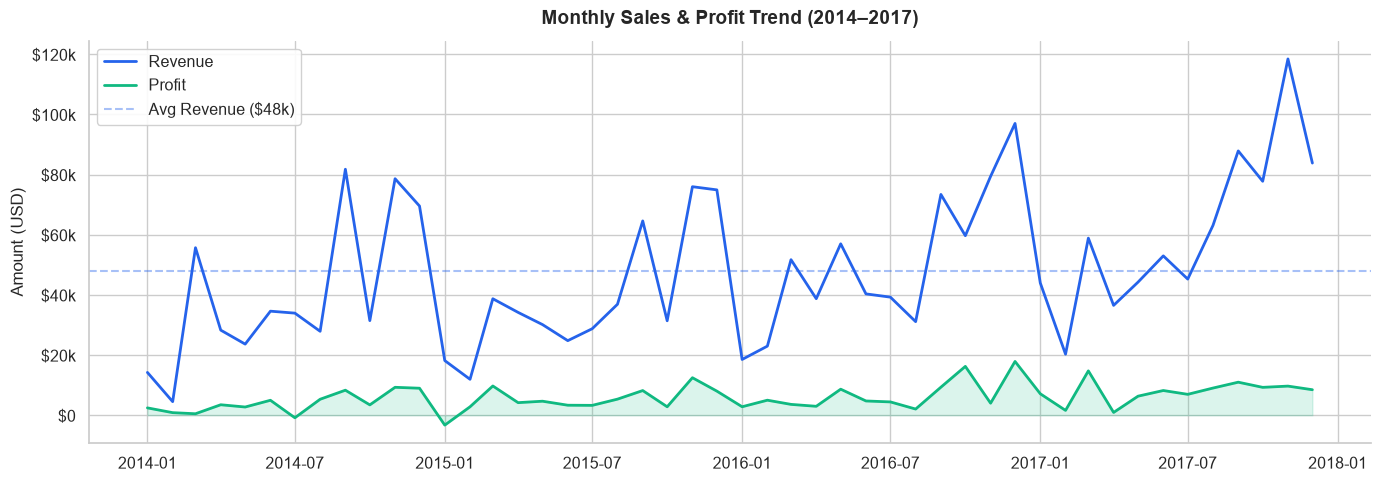

In [6]:
# Monthly aggregation
monthly = (
    df.set_index("order_date")
    .resample("MS")[["sales", "profit"]]
    .sum()
    .reset_index()
)
monthly["month_label"] = monthly["order_date"].dt.strftime("%b %Y")

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(monthly["order_date"], monthly["sales"], color=PALETTE[0], linewidth=2, label="Revenue")
ax.plot(monthly["order_date"], monthly["profit"], color=PALETTE[1], linewidth=2, label="Profit")
ax.fill_between(monthly["order_date"], monthly["profit"], alpha=0.15, color=PALETTE[1])
ax.axhline(y=monthly["sales"].mean(), color=PALETTE[0], linestyle="--", alpha=0.4, label=f"Avg Revenue ({fmt_dollar(monthly['sales'].mean())})")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_dollar))
ax.set_title("Monthly Sales & Profit Trend (2014–2017)", fontsize=14, fontweight="bold", pad=12)
ax.set_xlabel("")
ax.set_ylabel("Amount (USD)")
ax.legend(loc="upper left", framealpha=0.9)
sns.despine()
plt.tight_layout()
plt.show()

### 3.2 — Year-over-Year Comparison

Comparing annual performance to quantify growth.

In [7]:
yearly = df.groupby("order_year").agg(
    revenue=("sales", "sum"),
    profit=("profit", "sum"),
    orders=("order_id", "nunique"),
    qty=("quantity", "sum")
).reset_index()
yearly["margin"] = (yearly["profit"] / yearly["revenue"] * 100).round(1)
yearly["yoy_growth"] = yearly["revenue"].pct_change() * 100

print("Year-over-Year Performance")
print("=" * 65)
for _, row in yearly.iterrows():
    yoy = f"{row['yoy_growth']:+.1f}%" if pd.notna(row['yoy_growth']) else "  base"
    print(f"  {int(row['order_year'])}  │  Revenue: ${row['revenue']:>10,.0f}  │  Profit: ${row['profit']:>9,.0f}  │  Margin: {row['margin']}%  │  YoY: {yoy}")

Year-over-Year Performance
  2014  │  Revenue: $   484,247  │  Profit: $   49,544  │  Margin: 10.2%  │  YoY:   base
  2015  │  Revenue: $   470,533  │  Profit: $   61,619  │  Margin: 13.1%  │  YoY: -2.8%
  2016  │  Revenue: $   609,206  │  Profit: $   81,795  │  Margin: 13.4%  │  YoY: +29.5%
  2017  │  Revenue: $   733,215  │  Profit: $   93,439  │  Margin: 12.7%  │  YoY: +20.4%


### 3.3 — Seasonal Pattern Analysis

Averaging sales by month across all years to reveal seasonality.

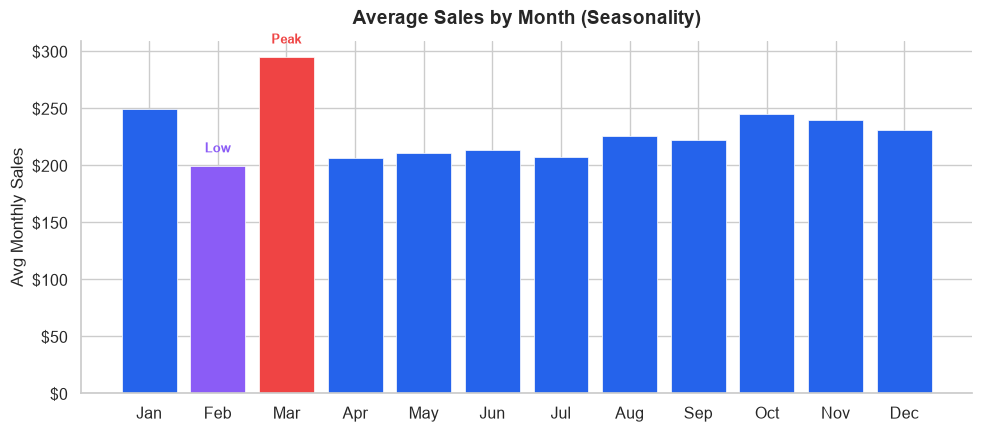

In [8]:
seasonal = df.groupby("order_month")["sales"].mean().reset_index()
month_names = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
               "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
seasonal["month_name"] = seasonal["order_month"].map(lambda m: month_names[m - 1])

fig, ax = plt.subplots(figsize=(10, 4.5))
colors = [PALETTE[3] if v == seasonal["sales"].max() else
          PALETTE[4] if v == seasonal["sales"].min() else
          PALETTE[0] for v in seasonal["sales"]]
bars = ax.bar(seasonal["month_name"], seasonal["sales"], color=colors, edgecolor="white", linewidth=0.5)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_dollar))
ax.set_title("Average Sales by Month (Seasonality)", fontsize=14, fontweight="bold", pad=12)
ax.set_xlabel("")
ax.set_ylabel("Avg Monthly Sales")

# Annotate peak and trough
peak_idx = seasonal["sales"].idxmax()
trough_idx = seasonal["sales"].idxmin()
ax.annotate(f"Peak", xy=(peak_idx, seasonal.loc[peak_idx, "sales"]),
            xytext=(0, 10), textcoords="offset points", ha="center",
            fontsize=9, fontweight="bold", color=PALETTE[3])
ax.annotate(f"Low", xy=(trough_idx, seasonal.loc[trough_idx, "sales"]),
            xytext=(0, 10), textcoords="offset points", ha="center",
            fontsize=9, fontweight="bold", color=PALETTE[4])

sns.despine()
plt.tight_layout()
plt.show()

---
## 4 · Regional Analysis

How does performance vary across US sales regions?  
We compare both revenue and profitability to identify strong and weak markets.

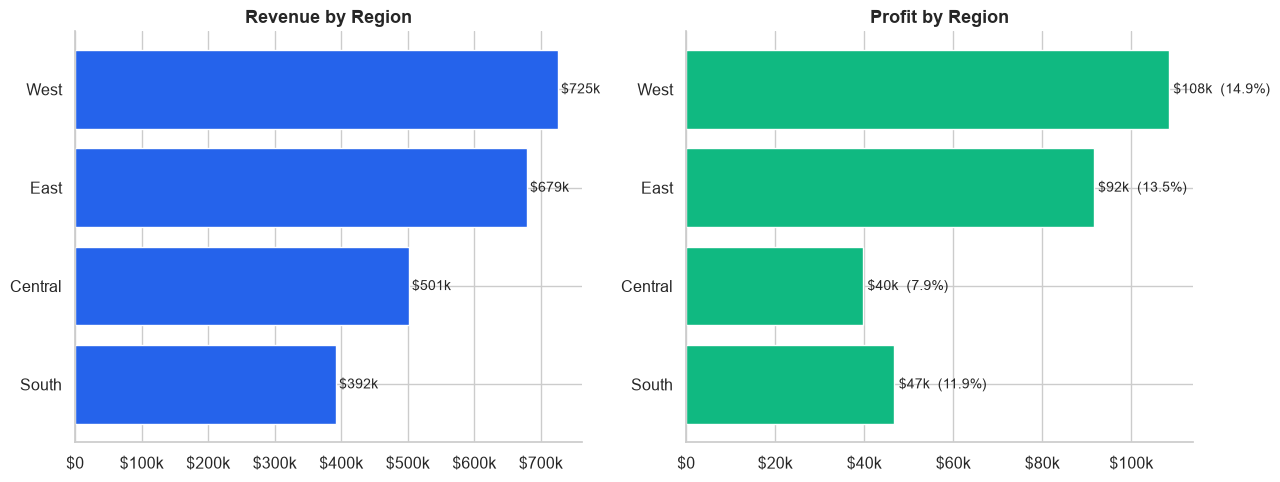


Regional Performance Summary:
 region   revenue    profit  margin  orders  loss_rate
   West 725457.82 108418.45   14.90    1611       9.90
   East 678781.24  91522.78   13.50    1401      19.40
Central 501239.89  39706.36    7.90    1175      31.90
  South 391721.91  46749.43   11.90     822      16.00


In [9]:
region_perf = df.groupby("region").agg(
    revenue=("sales", "sum"),
    profit=("profit", "sum"),
    orders=("order_id", "nunique"),
    avg_discount=("discount", "mean"),
    loss_rate=("is_loss", "mean")
).sort_values("revenue", ascending=False).reset_index()
region_perf["margin"] = (region_perf["profit"] / region_perf["revenue"] * 100).round(1)
region_perf["loss_rate"] = (region_perf["loss_rate"] * 100).round(1)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Revenue by region
ax1 = axes[0]
bars1 = ax1.barh(region_perf["region"], region_perf["revenue"], color=PALETTE[0], edgecolor="white")
ax1.xaxis.set_major_formatter(mticker.FuncFormatter(fmt_dollar))
ax1.set_title("Revenue by Region", fontsize=13, fontweight="bold")
ax1.invert_yaxis()
for bar, val in zip(bars1, region_perf["revenue"]):
    ax1.text(bar.get_width() + 5000, bar.get_y() + bar.get_height()/2,
             fmt_dollar(val), va="center", fontsize=10)

# Profit by region
ax2 = axes[1]
bars2 = ax2.barh(region_perf["region"], region_perf["profit"], color=PALETTE[1], edgecolor="white")
ax2.xaxis.set_major_formatter(mticker.FuncFormatter(fmt_dollar))
ax2.set_title("Profit by Region", fontsize=13, fontweight="bold")
ax2.invert_yaxis()
for bar, val, m in zip(bars2, region_perf["profit"], region_perf["margin"]):
    ax2.text(bar.get_width() + 1000, bar.get_y() + bar.get_height()/2,
             f"{fmt_dollar(val)}  ({m}%)", va="center", fontsize=10)

for ax in axes:
    sns.despine(ax=ax)

plt.tight_layout()
plt.show()

print("\nRegional Performance Summary:")
print(region_perf[["region", "revenue", "profit", "margin", "orders", "loss_rate"]].to_string(index=False))

---
## 5 · Category & Sub-Category Analysis

Drilling into product categories to understand **what sells** and **what is actually profitable**.

### 5.1 — Category Performance

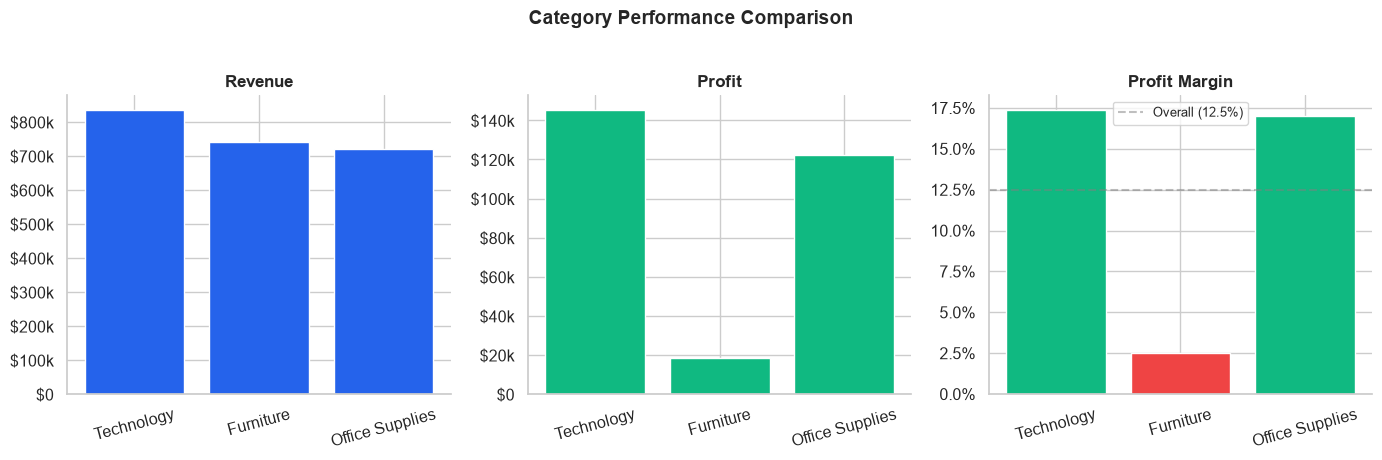

In [10]:
cat_perf = df.groupby("category").agg(
    revenue=("sales", "sum"),
    profit=("profit", "sum"),
    qty=("quantity", "sum"),
    avg_discount=("discount", "mean"),
    loss_rate=("is_loss", "mean")
).sort_values("revenue", ascending=False).reset_index()
cat_perf["margin"] = (cat_perf["profit"] / cat_perf["revenue"] * 100).round(1)

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))

# Revenue
axes[0].bar(cat_perf["category"], cat_perf["revenue"], color=PALETTE[0], edgecolor="white")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(fmt_dollar))
axes[0].set_title("Revenue", fontsize=12, fontweight="bold")

# Profit
axes[1].bar(cat_perf["category"], cat_perf["profit"], color=PALETTE[1], edgecolor="white")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(fmt_dollar))
axes[1].set_title("Profit", fontsize=12, fontweight="bold")

# Margin
bar_colors = [PALETTE[3] if m < 5 else PALETTE[1] for m in cat_perf["margin"]]
axes[2].bar(cat_perf["category"], cat_perf["margin"], color=bar_colors, edgecolor="white")
axes[2].yaxis.set_major_formatter(mticker.FuncFormatter(fmt_pct))
axes[2].set_title("Profit Margin", fontsize=12, fontweight="bold")
axes[2].axhline(y=overall_margin, color="gray", linestyle="--", alpha=0.5, label=f"Overall ({overall_margin:.1f}%)")
axes[2].legend(fontsize=9)

for ax in axes:
    ax.tick_params(axis="x", rotation=15)
    sns.despine(ax=ax)

plt.suptitle("Category Performance Comparison", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

### 5.2 — Sub-Category Profitability

Identifying high-performing and loss-making sub-categories. This is where the most actionable insights typically live.

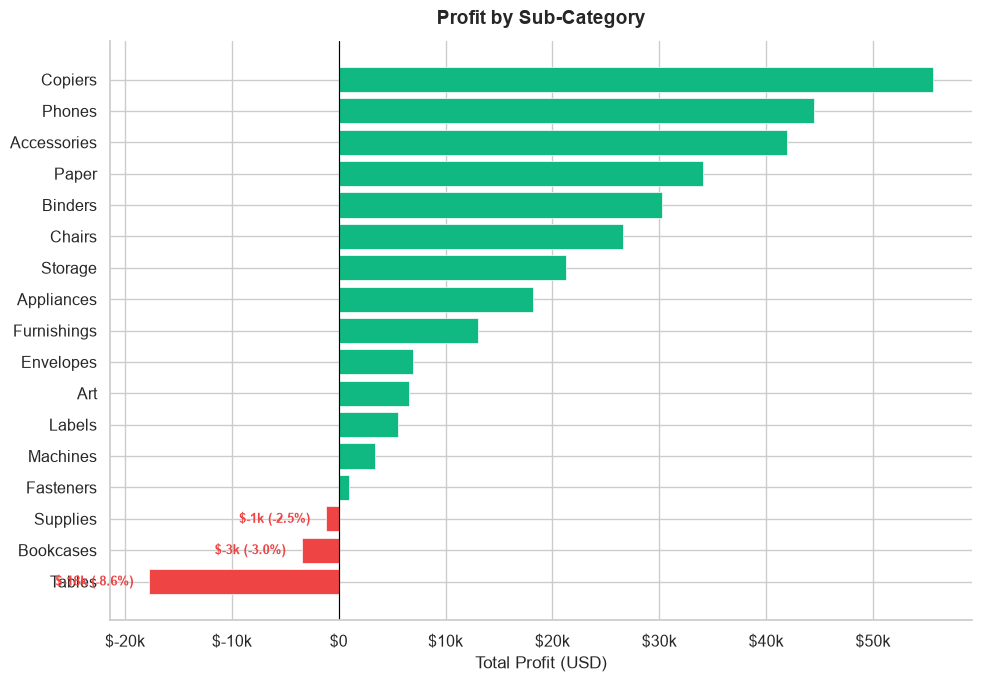

⚠️  Loss-making sub-categories:
   • Tables: profit = $-17,725  (margin: -8.6%)  on $206,966 revenue
   • Bookcases: profit = $-3,473  (margin: -3.0%)  on $114,880 revenue
   • Supplies: profit = $-1,189  (margin: -2.5%)  on $46,674 revenue


In [11]:
subcat = df.groupby("sub_category").agg(
    revenue=("sales", "sum"),
    profit=("profit", "sum")
).reset_index()
subcat["margin"] = (subcat["profit"] / subcat["revenue"] * 100).round(1)
subcat = subcat.sort_values("profit", ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))
colors = [PALETTE[3] if p < 0 else PALETTE[1] for p in subcat["profit"]]
bars = ax.barh(subcat["sub_category"], subcat["profit"], color=colors, edgecolor="white", linewidth=0.5)
ax.axvline(x=0, color="black", linewidth=0.8)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(fmt_dollar))
ax.set_title("Profit by Sub-Category", fontsize=14, fontweight="bold", pad=12)
ax.set_xlabel("Total Profit (USD)")

# Annotate loss-makers
for bar, (_, row) in zip(bars, subcat.iterrows()):
    if row["profit"] < 0:
        ax.text(bar.get_width() - 1500, bar.get_y() + bar.get_height()/2,
                f"{fmt_dollar(row['profit'])} ({row['margin']}%)",
                va="center", ha="right", fontsize=9, color=PALETTE[3], fontweight="bold")

sns.despine()
plt.tight_layout()
plt.show()

# Highlight problem areas
loss_subcats = subcat[subcat["profit"] < 0]
if len(loss_subcats) > 0:
    print("⚠️  Loss-making sub-categories:")
    for _, row in loss_subcats.iterrows():
        print(f"   • {row['sub_category']}: profit = ${row['profit']:,.0f}  (margin: {row['margin']}%)  on ${row['revenue']:,.0f} revenue")

---
## 6 · Customer Analysis

Identifying the most valuable customers — and those generating the most losses.

### 6.1 — Top 10 Customers by Revenue

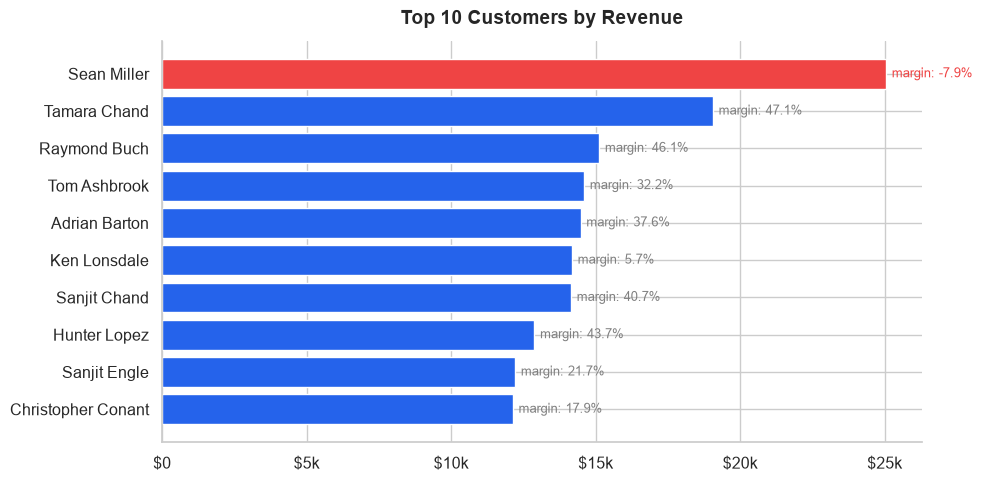

In [12]:
top_rev = (
    df.groupby("customer_name")
    .agg(revenue=("sales", "sum"), profit=("profit", "sum"), orders=("order_id", "nunique"))
    .sort_values("revenue", ascending=False)
    .head(10)
    .reset_index()
)
top_rev["margin"] = (top_rev["profit"] / top_rev["revenue"] * 100).round(1)

fig, ax = plt.subplots(figsize=(10, 5))
colors = [PALETTE[3] if m < 0 else PALETTE[0] for m in top_rev["margin"]]
bars = ax.barh(top_rev["customer_name"][::-1], top_rev["revenue"][::-1], color=colors[::-1], edgecolor="white")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(fmt_dollar))
ax.set_title("Top 10 Customers by Revenue", fontsize=14, fontweight="bold", pad=12)

for bar, margin in zip(bars, top_rev["margin"][::-1]):
    color = PALETTE[3] if margin < 0 else "gray"
    ax.text(bar.get_width() + 200, bar.get_y() + bar.get_height()/2,
            f"margin: {margin}%", va="center", fontsize=9, color=color)

sns.despine()
plt.tight_layout()
plt.show()

### 6.2 — Top 10 Customers by Profit

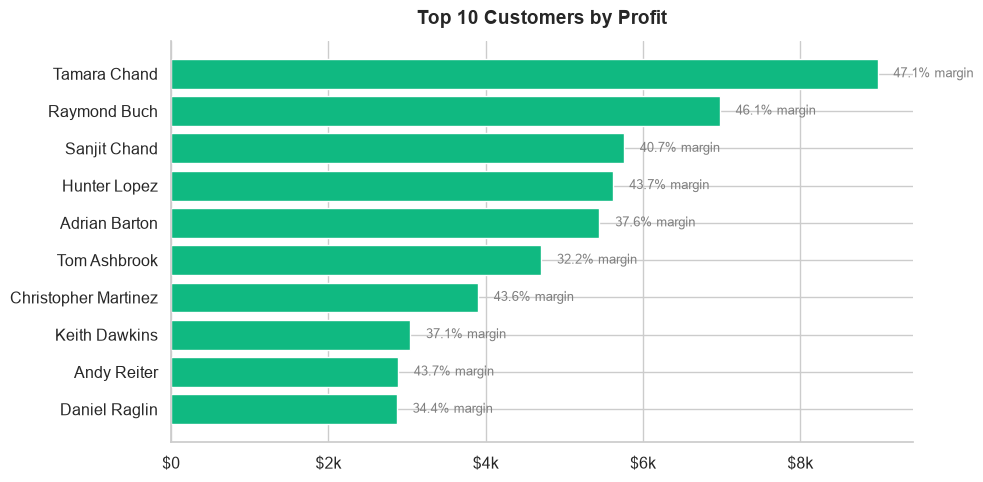

In [13]:
top_profit = (
    df.groupby("customer_name")
    .agg(revenue=("sales", "sum"), profit=("profit", "sum"), orders=("order_id", "nunique"))
    .sort_values("profit", ascending=False)
    .head(10)
    .reset_index()
)
top_profit["margin"] = (top_profit["profit"] / top_profit["revenue"] * 100).round(1)

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(top_profit["customer_name"][::-1], top_profit["profit"][::-1], color=PALETTE[1], edgecolor="white")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(fmt_dollar))
ax.set_title("Top 10 Customers by Profit", fontsize=14, fontweight="bold", pad=12)

for i, (_, row) in enumerate(top_profit[::-1].iterrows()):
    ax.text(row["profit"] + 100, i, f"  {row['margin']}% margin", va="center", fontsize=9, color="gray")

sns.despine()
plt.tight_layout()
plt.show()

---
## 7 · Discount Analysis

**Business question:** Does offering higher discounts actually drive profitability, or does it erode margins?  
Understanding this relationship is critical for pricing strategy.

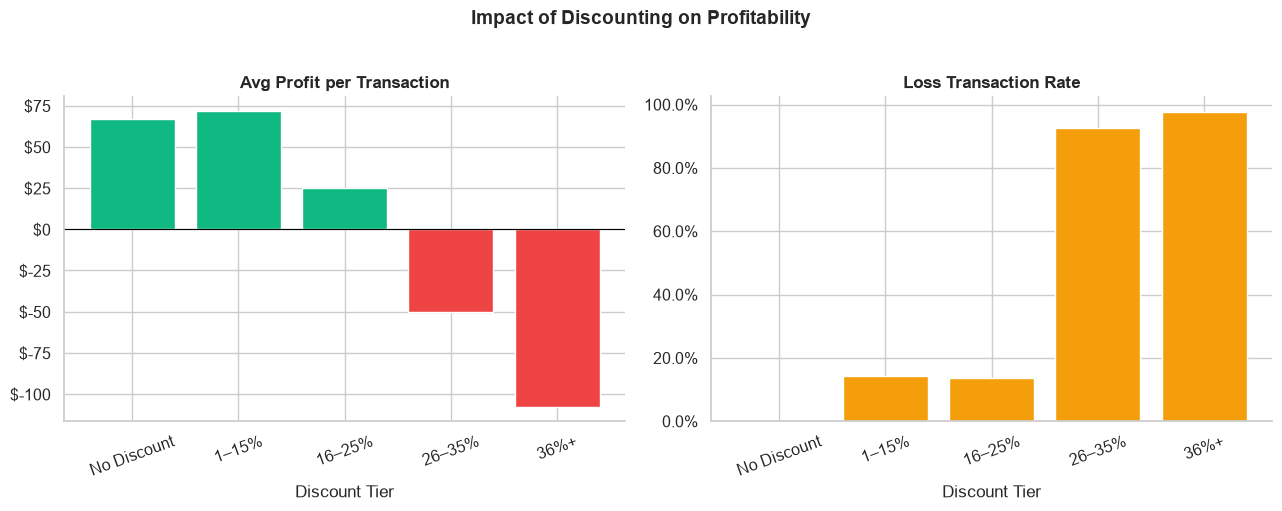

Discount Tier Summary:
discount_tier  count  avg_profit  total_profit  loss_rate
  No Discount   4798       66.90     320987.60       0.00
        1–15%    146       71.56      10448.17      14.40
       16–25%   3657       24.70      90337.31      13.70
       26–35%    254      -50.24     -12760.42      92.50
         36%+   1139     -107.65    -122615.64      97.70


In [14]:
# Bin discounts for clear comparison
bins = [0, 0.001, 0.15, 0.25, 0.35, 1.0]
labels = ["No Discount", "1–15%", "16–25%", "26–35%", "36%+"]
df["discount_tier"] = pd.cut(df["discount"], bins=bins, labels=labels, right=True, include_lowest=True)

disc_analysis = df.groupby("discount_tier", observed=True).agg(
    count=("sales", "size"),
    avg_profit=("profit", "mean"),
    total_profit=("profit", "sum"),
    loss_rate=("is_loss", "mean")
).reset_index()
disc_analysis["loss_rate"] = (disc_analysis["loss_rate"] * 100).round(1)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Avg profit per transaction by discount tier
ax1 = axes[0]
tier_colors = [PALETTE[1] if v > 0 else PALETTE[3] for v in disc_analysis["avg_profit"]]
ax1.bar(disc_analysis["discount_tier"], disc_analysis["avg_profit"], color=tier_colors, edgecolor="white")
ax1.axhline(y=0, color="black", linewidth=0.8)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_dollar))
ax1.set_title("Avg Profit per Transaction", fontsize=12, fontweight="bold")
ax1.set_xlabel("Discount Tier")
ax1.tick_params(axis="x", rotation=20)

# Loss rate by discount tier
ax2 = axes[1]
ax2.bar(disc_analysis["discount_tier"], disc_analysis["loss_rate"], color=PALETTE[2], edgecolor="white")
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_pct))
ax2.set_title("Loss Transaction Rate", fontsize=12, fontweight="bold")
ax2.set_xlabel("Discount Tier")
ax2.tick_params(axis="x", rotation=20)

for ax in axes:
    sns.despine(ax=ax)

plt.suptitle("Impact of Discounting on Profitability", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

print("Discount Tier Summary:")
print(disc_analysis.to_string(index=False))

### Discount vs. Profit Scatter

Visualizing the relationship at the transaction level.

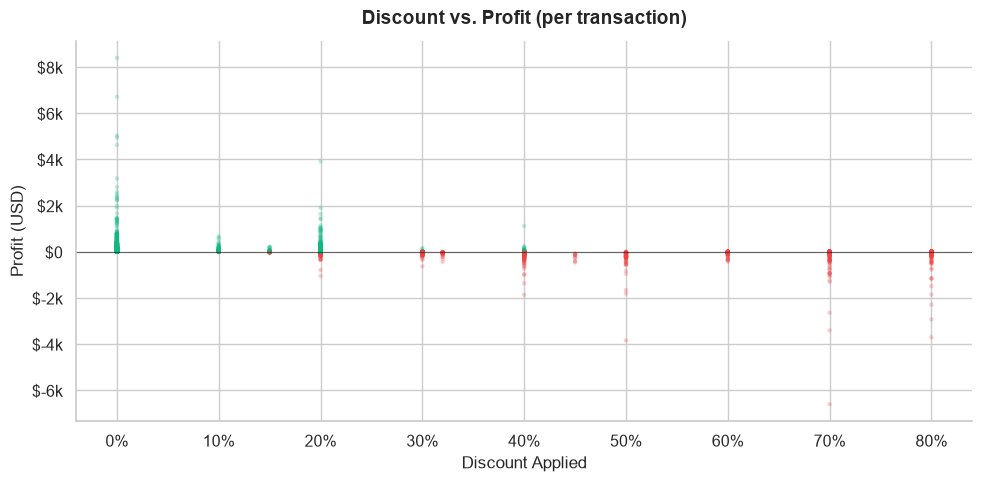

In [15]:
fig, ax = plt.subplots(figsize=(10, 5))
scatter = ax.scatter(
    df["discount"], df["profit"],
    c=df["profit"].apply(lambda x: PALETTE[1] if x >= 0 else PALETTE[3]),
    alpha=0.25, s=10, edgecolors="none"
)
ax.axhline(y=0, color="black", linewidth=0.8, alpha=0.5)
ax.set_title("Discount vs. Profit (per transaction)", fontsize=14, fontweight="bold", pad=12)
ax.set_xlabel("Discount Applied")
ax.set_ylabel("Profit (USD)")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0%}"))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_dollar))
sns.despine()
plt.tight_layout()
plt.show()

---
## 8 · Loss Analysis

18.7% of transactions are loss-making. Where exactly are these losses concentrated?  
This section breaks down losses by category, sub-category, and region.

In [16]:
losses = df[df["is_loss"]].copy()
total_loss = losses["profit"].sum()

print("Loss Overview")
print("=" * 50)
print(f"  Total loss-making transactions : {len(losses):,} ({len(losses)/len(df)*100:.1f}% of all)")
print(f"  Total loss amount              : ${total_loss:,.2f}")
print(f"  Average loss per transaction   : ${losses['profit'].mean():,.2f}")
print(f"  Worst single transaction       : ${losses['profit'].min():,.2f}")

Loss Overview
  Total loss-making transactions : 1,871 (18.7% of all)
  Total loss amount              : $-156,131.29
  Average loss per transaction   : $-83.45
  Worst single transaction       : $-6,599.98


### 8.1 — Losses by Category

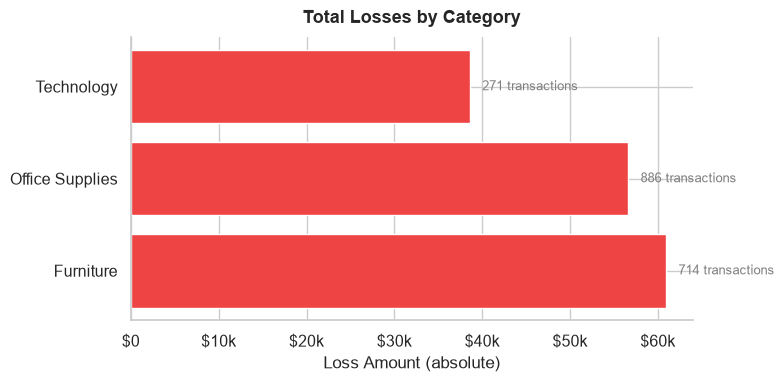

In [17]:
loss_by_cat = losses.groupby("category").agg(
    loss_count=("profit", "size"),
    total_loss=("profit", "sum"),
    avg_loss=("profit", "mean")
).sort_values("total_loss").reset_index()

fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(loss_by_cat["category"], loss_by_cat["total_loss"].abs(), color=PALETTE[3], edgecolor="white")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(fmt_dollar))
ax.set_title("Total Losses by Category", fontsize=13, fontweight="bold", pad=10)
ax.set_xlabel("Loss Amount (absolute)")

for i, (_, row) in enumerate(loss_by_cat.iterrows()):
    ax.text(abs(row["total_loss"]) + 500, i,
            f"  {row['loss_count']} transactions", va="center", fontsize=9, color="gray")

sns.despine()
plt.tight_layout()
plt.show()

### 8.2 — Losses by Sub-Category

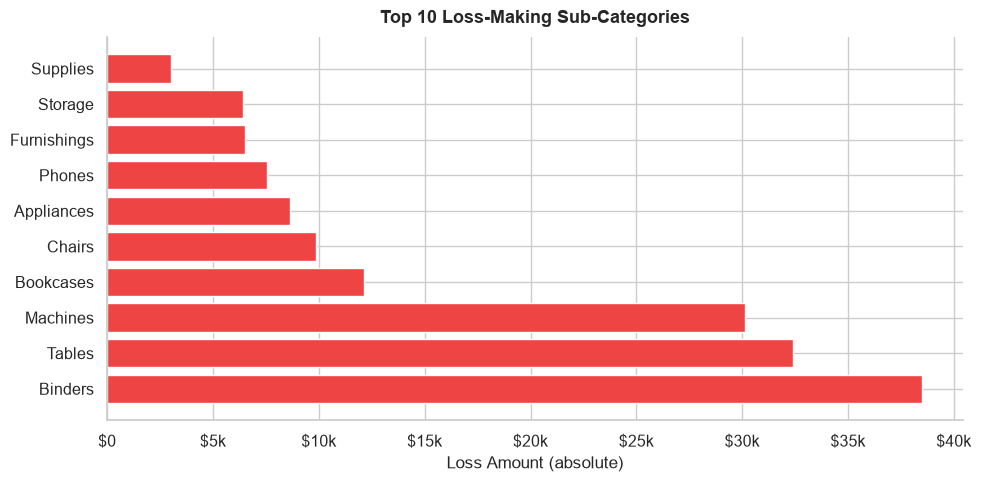

In [18]:
loss_by_subcat = losses.groupby("sub_category").agg(
    loss_count=("profit", "size"),
    total_loss=("profit", "sum")
).sort_values("total_loss").reset_index()

# Show top 10 loss-making sub-categories
top_loss_sc = loss_by_subcat.head(10)

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(top_loss_sc["sub_category"], top_loss_sc["total_loss"].abs(), color=PALETTE[3], edgecolor="white")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(fmt_dollar))
ax.set_title("Top 10 Loss-Making Sub-Categories", fontsize=13, fontweight="bold", pad=10)
ax.set_xlabel("Loss Amount (absolute)")
sns.despine()
plt.tight_layout()
plt.show()

### 8.3 — Losses by Region

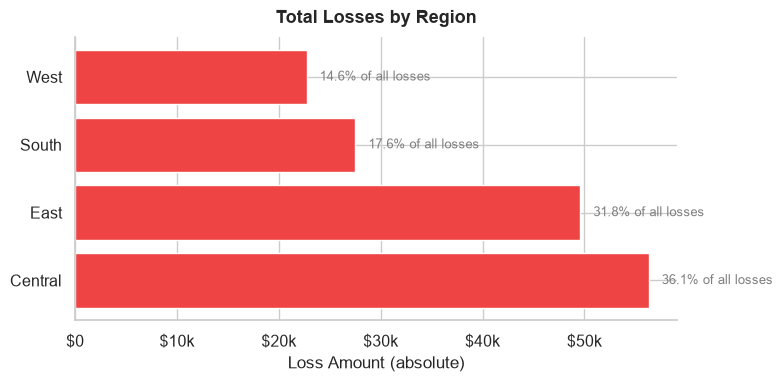

In [19]:
loss_by_region = losses.groupby("region").agg(
    loss_count=("profit", "size"),
    total_loss=("profit", "sum")
).sort_values("total_loss").reset_index()
loss_by_region["pct_of_total"] = (loss_by_region["total_loss"] / total_loss * 100).round(1)

fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(loss_by_region["region"], loss_by_region["total_loss"].abs(), color=PALETTE[3], edgecolor="white")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(fmt_dollar))
ax.set_title("Total Losses by Region", fontsize=13, fontweight="bold", pad=10)
ax.set_xlabel("Loss Amount (absolute)")

for i, (_, row) in enumerate(loss_by_region.iterrows()):
    ax.text(abs(row["total_loss"]) + 500, i,
            f"  {row['pct_of_total']}% of all losses", va="center", fontsize=9, color="gray")

sns.despine()
plt.tight_layout()
plt.show()

### 8.4 — Profit Margin Distribution

As noted in the data dictionary, `profit_margin` has extreme outliers. Let's inspect the distribution.

profit_margin distribution:
count   9994.00
mean       0.12
std        0.47
min       -2.75
25%        0.07
50%        0.27
75%        0.36
max        0.50

Values below -1.0: 349
Values below -0.5: 869


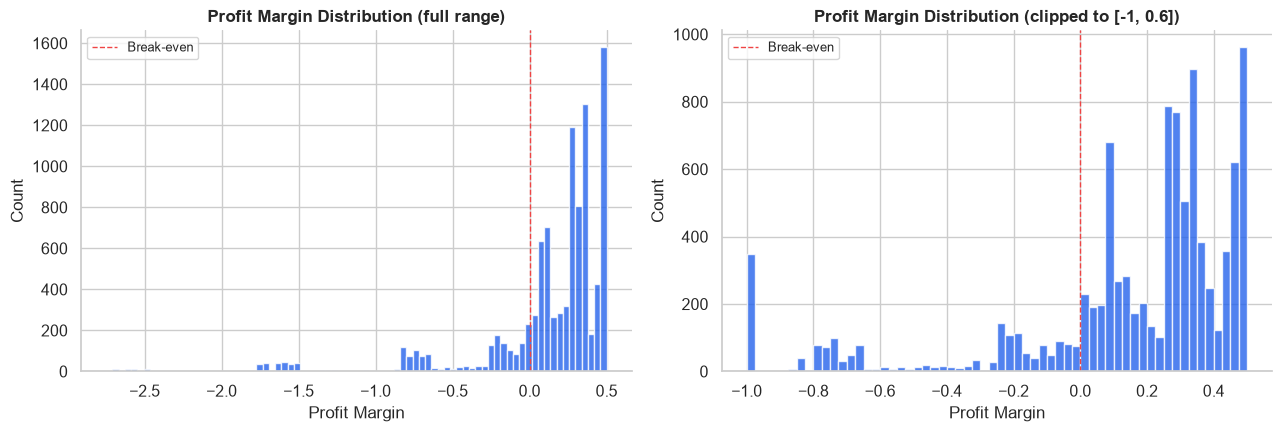


💡 Outlier Guidance: Extreme negative margins (< -1.0) represent transactions
   where losses exceeded the sale price. These are valid but may need special
   treatment (e.g., winsorizing) in ML models. See docs/data_dictionary.md.


In [20]:
print("profit_margin distribution:")
print(df["profit_margin"].describe().to_string())
print(f"\nValues below -1.0: {(df['profit_margin'] < -1.0).sum()}")
print(f"Values below -0.5: {(df['profit_margin'] < -0.5).sum()}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Full distribution
axes[0].hist(df["profit_margin"], bins=80, color=PALETTE[0], edgecolor="white", alpha=0.8)
axes[0].axvline(x=0, color=PALETTE[3], linestyle="--", linewidth=1, label="Break-even")
axes[0].set_title("Profit Margin Distribution (full range)", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Profit Margin")
axes[0].set_ylabel("Count")
axes[0].legend(fontsize=9)

# Zoomed to [-1, 0.6] for clarity
clipped = df["profit_margin"].clip(-1, 0.6)
axes[1].hist(clipped, bins=60, color=PALETTE[0], edgecolor="white", alpha=0.8)
axes[1].axvline(x=0, color=PALETTE[3], linestyle="--", linewidth=1, label="Break-even")
axes[1].set_title("Profit Margin Distribution (clipped to [-1, 0.6])", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Profit Margin")
axes[1].set_ylabel("Count")
axes[1].legend(fontsize=9)

for ax in axes:
    sns.despine(ax=ax)

plt.tight_layout()
plt.show()

print("\n💡 Outlier Guidance: Extreme negative margins (< -1.0) represent transactions")
print("   where losses exceeded the sale price. These are valid but may need special")
print("   treatment (e.g., winsorizing) in ML models. See docs/data_dictionary.md.")

---
## 9 · Forecast Preparation

The forecasting model (`03_forecasting.ipynb`) requires a clean monthly time series.  
We aggregate sales to the monthly level and export as a standalone CSV.

In [21]:
monthly_sales = (
    df.set_index("order_date")
    .resample("MS")["sales"]
    .sum()
    .reset_index()
)
monthly_sales.columns = ["date", "revenue"]

# Verify completeness
expected_months = 48  # 4 years × 12 months
actual_months = len(monthly_sales)
print(f"Monthly time series: {actual_months} months (expected: {expected_months})")
print(f"Date range: {monthly_sales['date'].min().date()} → {monthly_sales['date'].max().date()}")
print(f"Revenue range: ${monthly_sales['revenue'].min():,.0f} → ${monthly_sales['revenue'].max():,.0f}")
print()
monthly_sales.head(6)

Monthly time series: 48 months (expected: 48)
Date range: 2014-01-01 → 2017-12-01
Revenue range: $4,520 → $118,448



,date,revenue
0,2014-01-01,14236.90
1,2014-02-01,4519.89
2,2014-03-01,55691.01
3,2014-04-01,28295.35
4,2014-05-01,23648.29
5,2014-06-01,34595.13


In [22]:
# Export
OUTPUT_DIR  = os.path.join("..", "data", "processed")
if not os.path.exists(OUTPUT_DIR):
    OUTPUT_DIR = os.path.join("data", "processed")

OUTPUT_PATH = os.path.join(OUTPUT_DIR, "monthly_sales.csv")
monthly_sales.to_csv(OUTPUT_PATH, index=False)

file_size = os.path.getsize(OUTPUT_PATH)
print(f"✅ Exported: {OUTPUT_PATH}")
print(f"   Size : {file_size:,} bytes")
print(f"   Rows : {len(monthly_sales)}")
print(f"   Cols : {list(monthly_sales.columns)}")

✅ Exported: ..\data\processed\monthly_sales.csv
   Size : 1,110 bytes
   Rows : 48
   Cols : ['date', 'revenue']


### Forecast Time Series Preview

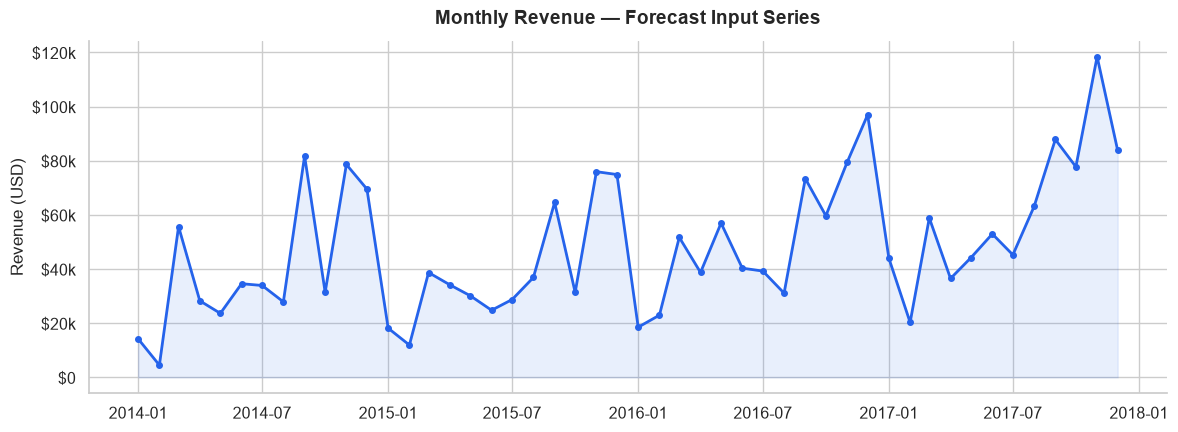

In [23]:
fig, ax = plt.subplots(figsize=(12, 4.5))
ax.plot(monthly_sales["date"], monthly_sales["revenue"], color=PALETTE[0], linewidth=2, marker="o", markersize=4)
ax.fill_between(monthly_sales["date"], monthly_sales["revenue"], alpha=0.1, color=PALETTE[0])
ax.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_dollar))
ax.set_title("Monthly Revenue — Forecast Input Series", fontsize=14, fontweight="bold", pad=12)
ax.set_xlabel("")
ax.set_ylabel("Revenue (USD)")
sns.despine()
plt.tight_layout()
plt.show()

---
## 📋 Key Business Insights

### Revenue & Growth
- **Total revenue: $2.30M** with **$286K profit** (12.5% margin) across 4 years (2014–2017).
- Revenue has grown consistently year-over-year, demonstrating a healthy business trajectory.
- **Seasonality is pronounced:** sales peak in November–December (holiday season) and dip in January–February.

### Regional Performance
- **West** is the top-performing region in both revenue ($725K) and profit ($108K).
- **Central** region has the **lowest profit margin** — it warrants investigation into pricing and discount strategies.
- **East** is a strong performer with balanced revenue and profit.

### Product Insights
- **Technology** leads in profit ($145K, 17.4% margin) despite not being the highest-revenue category.
- **Furniture is a problem category:** high revenue ($742K) but near-zero margin (2.5%). The margin is dragged down by **Tables** and **Bookcases**, which are outright loss-makers.
- **Copiers** are the most profitable sub-category — low volume but extremely high margins.

### Discount Impact
- **Discounts above 25% consistently destroy profitability.** Transactions with 36%+ discounts have negative average profit and a very high loss rate.
- Zero-discount transactions are the most reliably profitable.
- **Recommendation:** Review and cap discount policies, especially for Furniture items.

### Loss Analysis
- **18.7% of all transactions are loss-making**, totaling **$156K in losses**.
- Losses are concentrated in the **Central** region and **Furniture** category (Tables, Bookcases).
- Heavy discounting is the primary driver of losses.

### Actionable Recommendations for the AI Agent

| Priority | Recommendation |
|---|---|
| 🔴 High | Investigate and reduce discounting on Tables and Bookcases |
| 🔴 High | Cap discount levels at 25% unless strategically justified |
| 🟡 Medium | Focus growth efforts on Technology (highest-margin category) |
| 🟡 Medium | Audit Central region pricing and operations |
| 🟢 Low | Expand Copier sales — highest-margin sub-category |

---

**Next Steps:**
- ➡️ `03_forecasting.ipynb` — Build a sales forecasting model using the monthly series
- ➡️ `agent/` — Power the LangGraph AI agent with these insights
- ➡️ `dashboard/` — Visualize KPIs in Power BI

---
*Notebook created for the AI-Powered Sales Intelligence Platform.*